# **NLP Project : Youtube Comments Classification** 🔡👨🏻‍💻📝

## 1️⃣ Required Libraries

In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import time

# NLP
import spacy
import re
nlp = spacy.load("en_core_web_sm")
from sklearn.feature_extraction.text import CountVectorizer

# Fine Tuning 
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
import torch
from torch import nn
from transformers import Trainer

C:\Users\moham\anaconda3\envs\nlp_egypt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2️⃣ Read Dataset

In [2]:
path_train = './train.csv'
df_train = pd.read_csv(path_train)

In [3]:
df_train.shape

(159571, 8)

In [4]:
df_train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


### 📊 Dataset Overview

The dataset used in this project is part of the famous **"Jigsaw Toxic Comment Classification Challenge"** hosted on Kaggle. The goal is to build models capable of identifying and classifying "toxic" content in online comments to help improve the quality of digital discussions.

##### 🌐 Sources
* **Platform:** [Kaggle - Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data).
* **Provider:** The data was provided by the **Conversation AI** team, a research initiative involving **Jigsaw** (an Alphabet company) and **Google**.
* **Origin:** The dataset consists of a large number of Wikipedia comments which have been labeled by human raters for toxic behavior.

##### 📋 Data Structure
The dataset contains over **159,000** records in the training set. It follows a **multi-label classification** format, meaning a single comment can belong to multiple categories simultaneously (e.g., a comment can be both "obscene" and "insult").

**Main Columns:**
1.  `id`: A unique identifier for each comment.
2.  `comment_text`: The raw text of the comment to be analyzed.
3.  **Target Labels:** There are 6 binary categories to predict:
    * `toxic`: General toxicity.
    * `severe_toxic`: High level of toxicity.
    * `obscene`: Profanity/Vulgarity.
    * `threat`: Threats of violence.
    * `insult`: Personal attacks.
    * `identity_hate`: Hate speech targeting identity.

##### 🔬 Significance in NLP
This dataset is chosen because it presents significant challenges:
* **Class Imbalance:** The vast majority of comments are non-toxic, while offensive categories represent a small fraction of the data. This requires specialized techniques to ensure the model learns correctly from rare classes.
* **Contextual Understanding:** Distinguishing between "harsh criticism" and "insult" requires deep contextual understanding, making Transformer models like **DistilBERT** an ideal choice for this task.

## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


### Check Columns

In [6]:
df_train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [7]:
df_train.drop(columns=['id'], axis=1, inplace=True)

### Missing Values

In [8]:
df_train.isna().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

### Duplication Values

In [9]:
df_train.duplicated().sum()

np.int64(0)

### Number of normal and unnormal comments

In [10]:
cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
count = (df_train[cols] == 0).all(axis=1).sum()
print(count)

143346


### Percentage Each Label

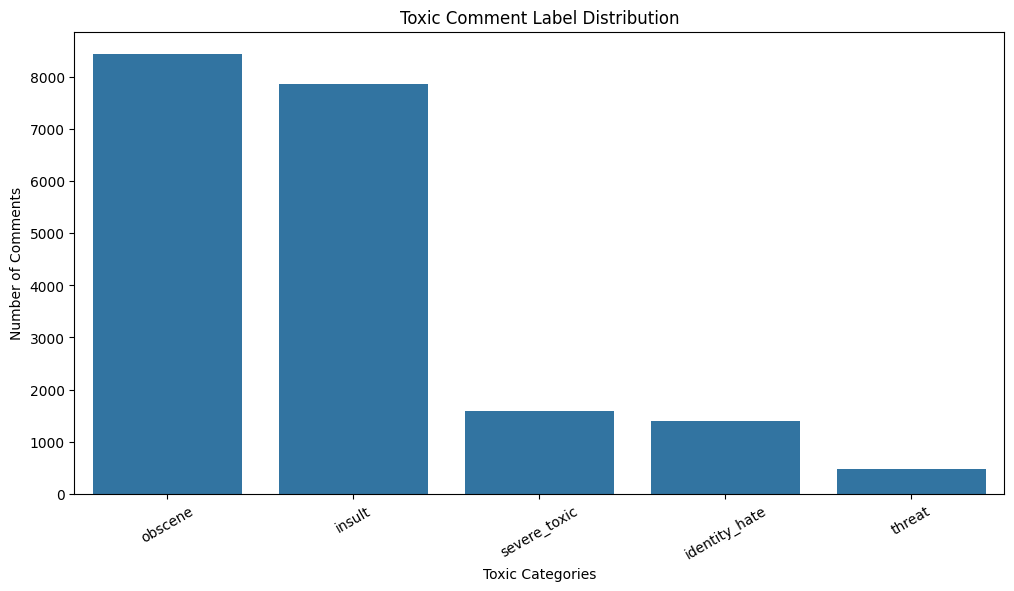

In [11]:
labels = df_train.columns[2:]
counts = df_train[labels].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=counts.index, y=counts.values)

plt.title("Toxic Comment Label Distribution")
plt.ylabel("Number of Comments")
plt.xlabel("Toxic Categories")

plt.xticks(rotation=30)
plt.show()

### Comment length Histogram

In [12]:
df_train["comment_length"] = df_train["comment_text"].str.len()

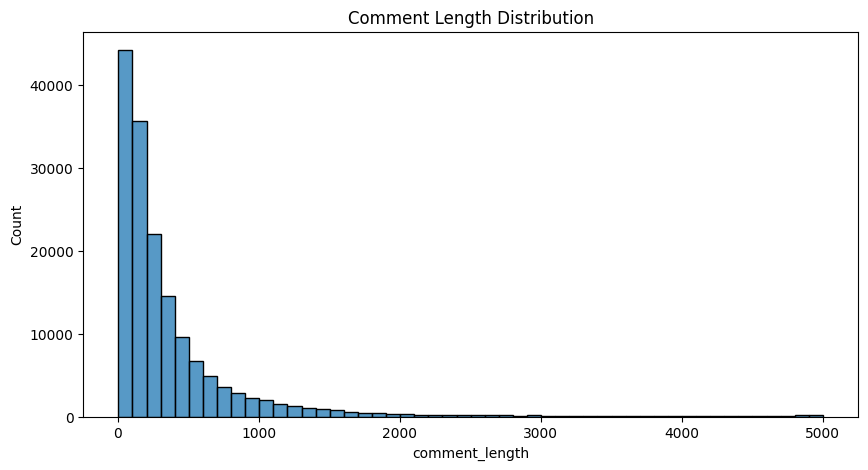

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df_train["comment_length"], bins=50)
plt.title("Comment Length Distribution")
plt.show()

### Boxplot: Comment Length vs Toxicity

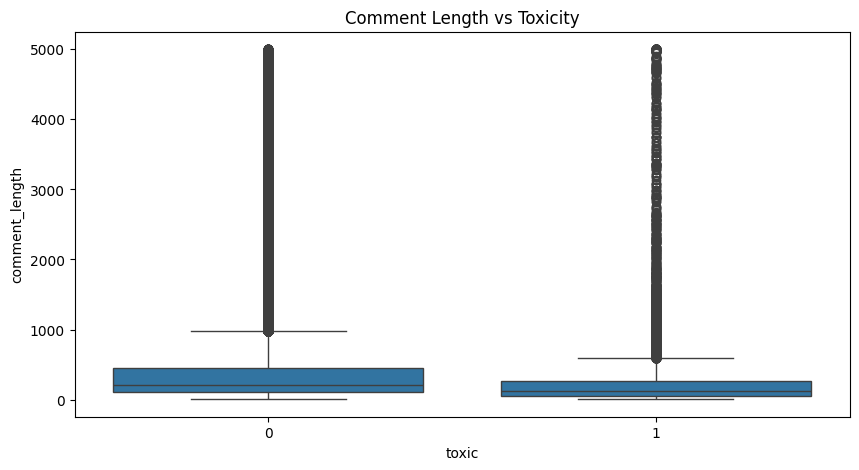

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_train["toxic"], y=df_train["comment_length"])
plt.title("Comment Length vs Toxicity")
plt.show()

### Function : Analysis Text

In [15]:
def analyze_text(text):
    # 1. Show Original Text
    print('\n-- 🔹 1. Original Text --')
    print('Text:', text)
    print('-' * 20)

    # 2. Basic Cleaning
    print('-- 🔹 2. Cleaned Text (Preprocessing) --')
    text_cleaned = re.sub(r"https?://\S+|www\.\S+", "", text) # Remove URLs
    text_cleaned = re.sub(r"[^a-zA-Z\s]", "", text_cleaned) # Remove symbols and numbers (Optional)
    print('Cleaned:', text_cleaned)
    print('-' * 20)

    # Process text with SpaCy once for all subsequent steps
    doc = nlp(text_cleaned.lower())

    # 3. Tokenization & Lemmatization
    # Lemma is better than Stemming as it returns the correct linguistic root
    print('-- 🔹 3. Tokens & Lemmas --')
    tokens = []
    lemmas = []
    for token in doc:
        tokens.append(token.text)
        lemmas.append(token.lemma_)

    print('Tokens:', tokens)
    print('Lemmas (Roots):', lemmas)
    print('-' * 20)

    # 4. StopWords & Final Filtering
    # Extracting the clean sentence for the Machine Learning model
    print('-- 🔹 4. Filtered Text (No Stopwords) --')
    filtered_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    final_text = " ".join(filtered_tokens)

    print('Filtered Tokens:', filtered_tokens)
    print('Final Ready Text:', final_text)
    print('-' * 20)

    # 5. POS Tagging (Part of Speech)
    # Performed on the full context (doc) for better accuracy
    print('-- 🔹 5. POS Analysis (Meaning) --')
    for token in list(doc):
        print(f"Word: {token.text:10} | Tag: {token.pos_:6} | Explain: {spacy.explain(token.pos_)}")
    print('-' * 20)

    return final_text

In [16]:
# Testing the function
my_comment = df_train.comment_text[0]
final_output = analyze_text(my_comment)


-- 🔹 1. Original Text --
Text: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
--------------------
-- 🔹 2. Cleaned Text (Preprocessing) --
Cleaned: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted They werent vandalisms just closure on some GAs after I voted at New York Dolls FAC And please dont remove the template from the talk page since Im retired now
--------------------
-- 🔹 3. Tokens & Lemmas --
Tokens: ['explanation', '\n', 'why', 'the', 'edits', 'made', 'under', 'my', 'username', 'hardcore', 'metallica', 'fan', 'were', 'reverted', 'they', 'were', 'nt', 'vandalisms', 'just', 'closure', 'on', 'some', 'gas', 'after', 'i', 'voted', 'at', 'new', 'york', 'dolls', 'fac', 'and', 'please', 'do', 'nt', 'remove', 'the', 'template', 'from

### Correlation Matrix

In [17]:
# Define your target columns
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [18]:
def plot_correlation(df):
    plt.figure(figsize=(10, 8))
    # Calculate Pearson correlation between labels
    correlation = df[target_cols].corr()
    sns.heatmap(correlation, annot=True, cmap='Reds', fmt=".2f", linewidths=.5)
    plt.title('Correlation Between Toxic Labels', fontsize=15)
    plt.show()

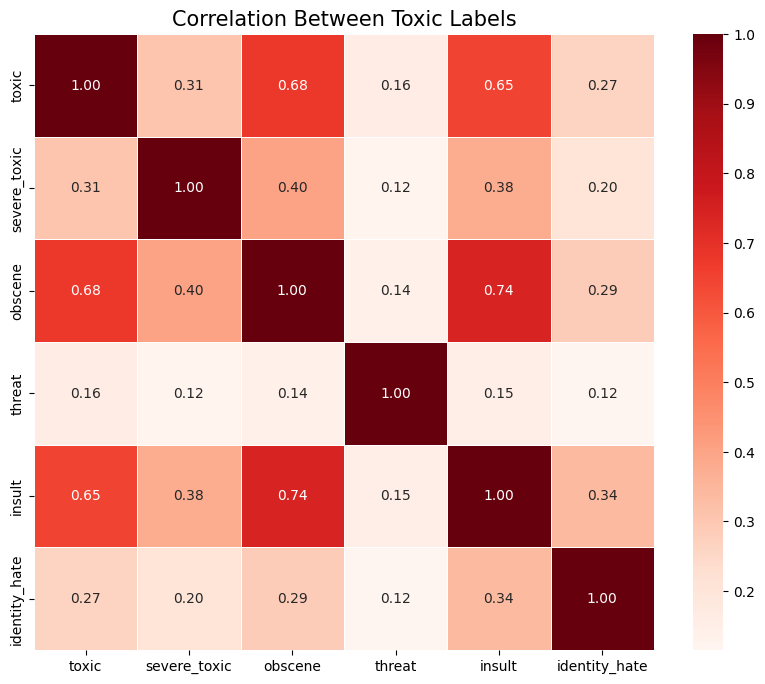

In [19]:
plot_correlation(df_train)

## 4️⃣ Data Preprocessing

In [20]:
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
target_cols

['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [21]:
counts = df_train[target_cols].sum().values
total = len(df_train)
pos_weights = torch.tensor((total - counts) / counts, dtype=torch.float).to("cuda")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [22]:
df_train_full, df_val_full = train_test_split(
    df_train, 
    test_size=0.10, 
    random_state=42,
    shuffle=True
)

In [23]:
def tokenize_and_encode(examples):
    return tokenizer(examples["comment_text"], truncation=True, padding="max_length", max_length=128)

In [24]:
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
df_train_full['labels'] = df_train_full[target_cols].values.astype(float).tolist()
df_val_full['labels'] = df_val_full[target_cols].values.astype(float).tolist()

train_ds = Dataset.from_pandas(df_train_full[['comment_text', 'labels']])
val_ds = Dataset.from_pandas(df_val_full[['comment_text', 'labels']])

train_ds = train_ds.map(tokenize_and_encode, batched=True)
val_ds = val_ds.map(tokenize_and_encode, batched=True)

Map: 100%|██████████████████████████████████████████████████████████████| 15958/15958 [00:02<00:00, 7671.31 examples/s]


## 6️⃣ Modeling

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=6, problem_type="multi_label_classification"
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 7565.48it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 🤖 Why was the DistilBERT Model Chosen for this Project?

After conducting initial experiments with traditional machine learning models (Baselines) such as **Logistic Regression**, we transitioned to using Deep Learning techniques based on **Transformers**. **DistilBERT** was selected as the optimal choice for this task based on several technical and practical factors:

##### 1. Balance Between Performance and Efficiency ⚡
* **DistilBERT** is a "distilled" or compressed version of the original **BERT** model; it is **40% smaller** and **60% faster**.
* Despite its reduced size, it retains approximately **97%** of BERT's superior language understanding capabilities, making it the fastest option for Fine-tuning and Inference without sacrificing significant accuracy.

##### 2. Hardware Resource Optimization 💻
* Since the training is conducted on limited local resources (such as a laptop **RTX 3060 GPU**), DistilBERT consumes significantly less **VRAM** compared to heavier models like **BERT-base** or **RoBERTa**.
* This allowed us to use a sufficient **Batch Size** (e.g., 16) and complete the entire training process in record time (less than an hour for the full dataset).

##### 3. Superiority over Traditional Models (Contextual Awareness) 🧠
* Traditional models like Logistic Regression rely on word frequencies (**TF-IDF**), whereas DistilBERT understands the **"Context"** of the entire sentence.
* This deep understanding helped the model handle complex and overlapping categories in the **Jigsaw** dataset, such as differentiating between general `toxic` comments and specific `insult` or `obscene` labels.

##### 4. Analysis of Achieved Results 📈
* The final results showed remarkable success, with the **ROC-AUC**.
* The **Learning Curves** demonstrate high stability and close convergence between the **Training Loss** and **Validation Loss**, confirming that the model selection was precise enough to avoid **Overfitting** issues.

**Conclusion:** DistilBERT was chosen because it provided near state-of-the-art performance while offering massive savings in time and computational resources.

In [27]:
args = TrainingArguments(
    output_dir="./distilbert-toxic-test",
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,  
    warmup_ratio=0.1,               
    lr_scheduler_type="cosine",      
    
    num_train_epochs=1, 
    weight_decay=0.01,
    fp16=True, 
    load_best_model_at_end=True, 
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    predictions = (probs > 0.5).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc_score(labels, probs, average='macro')
    }
    
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics, 
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### 🧠 Understanding the Enhanced Model Training Configuration

When fine-tuning a model like **DistilBERT** for text classification, we provide a set of "instructions" that dictate how the model should learn. Below is a breakdown of the updated parameters used to ensure a stable and high-performing training process:

##### 1. Advanced Training Setup (`TrainingArguments`)
These arguments act as the "control panel" for the learning process, now optimized for smoother convergence:

* **`output_dir`**: The directory where the model's weights and training checkpoints will be saved.
* **`eval_strategy`**: This determines the evaluation schedule. Setting it to `"steps"` tells the model to test itself after a specific number of training steps.
* **`eval_steps`**: Set to `500`, meaning the model pauses every 500 steps to evaluate its performance on the validation set.
* **`learning_rate`**: The "step size" the model takes when correcting its errors. A rate of `2e-5` ensures stable learning.
* **`per_device_train_batch_size`**: The number of samples processed on the GPU at once (set to `16`).
* **`gradient_accumulation_steps`**: **(New)** Set to `4`. This allows the model to calculate gradients over 4 batches before updating weights. It effectively simulates a larger batch size (16 x 4 = 64) without requiring extra GPU memory, leading to a smoother Loss curve.
* **`warmup_ratio`**: **(New)** Set to `0.1`. The first 10% of training steps use a very low learning rate that gradually increases. This "pre-heating" phase prevents the model from diverging or "getting lost" at the very start.
* **`lr_scheduler_type`**: **(New)** Set to `"cosine"`. This adjusts the learning rate following a cosine curve, gradually decreasing it as training progresses to help the model settle into the global minimum.
* **`fp16` (Mixed Precision)**: Uses 16-bit numbers for calculations to speed up training by up to 50% and reduce VRAM usage.
* **`load_best_model_at_end`**: Ensures the final model saved is the version that achieved the best performance on validation metrics.

##### 2. The Multi-Label Grader (`compute_metrics`)
This function acts as the "exam corrector." Since we are dealing with 6 different toxic categories at once, it calculates:

* **`probs` (Sigmoid)**: Converts raw model outputs into probabilities between 0 and 1 for each label.
* **`ROC-AUC`**: The primary metric measuring the model's ability to distinguish between classes.
* **`F1, Precision, & Recall`**: Metrics that balance the model's ability to find all toxic comments (Recall) against its accuracy in labeling them correctly (Precision).

##### 3. The Specialized Coordinator (`WeightedTrainer`)
Unlike a standard trainer, the **`WeightedTrainer`** is designed to handle "Class Imbalance":

* **`compute_loss`**: This custom function uses the `pos_weight` we calculated. It forces the model to pay much more attention to rare classes (like `threat` or `identity_hate`) by penalizing mistakes in those categories more heavily.

***

**In Summary:** You have upgraded your "classroom" from a standard setup to a high-performance lab. By adding **Gradient Accumulation**, **Warmup**, and a **Cosine Scheduler**, you are ensuring that the model doesn't just learn, but learns with a steady, calculated "rhythm" that results in a much cleaner and more professional training curve.

In [28]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
500,1.909671,0.359110,0.871036,0.445821,0.340639,0.908178,0.980371
1000,1.650340,0.263604,0.841960,0.433087,0.309335,0.958121,0.987376
1500,1.385878,0.247504,0.865209,0.467774,0.343050,0.958029,0.989065
2000,1.473777,0.240824,0.865334,0.505882,0.373894,0.949759,0.990138
2244,1.137624,0.243333,0.866211,0.509222,0.377067,0.942461,0.990133


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.73it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2244, training_loss=1.72151093304476, metrics={'train_runtime': 715.7017, 'train_samples_per_second': 200.66, 'train_steps_per_second': 3.135, 'total_flos': 4756349397551616.0, 'train_loss': 1.72151093304476, 'epoch': 1.0})

### Evaluation

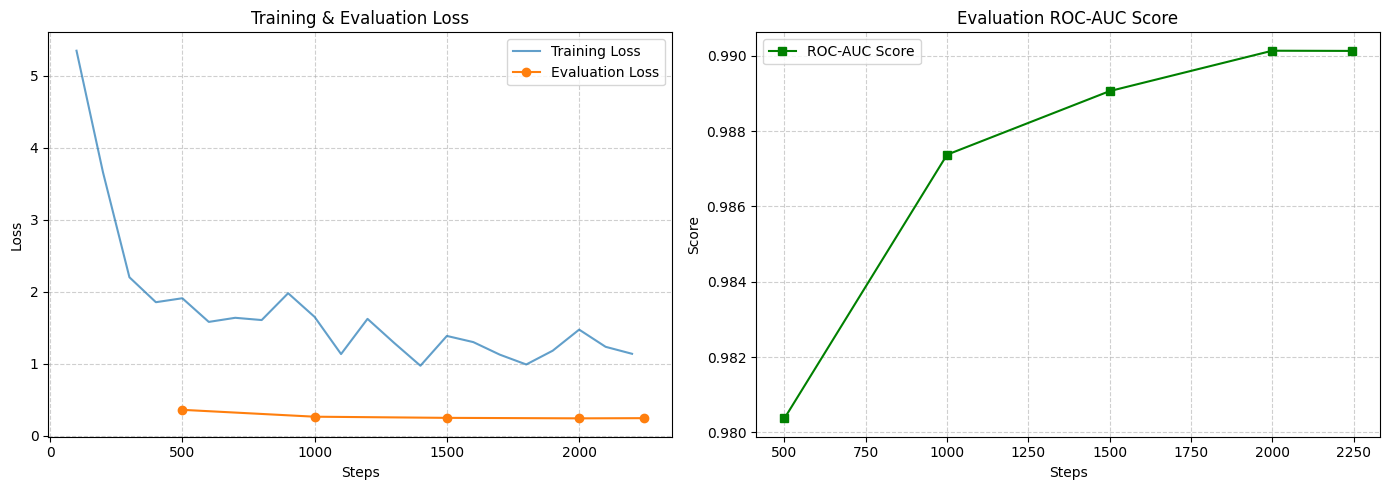

In [29]:
history = pd.DataFrame(trainer.state.log_history)

train_logs = history[history['loss'].notna()]
eval_logs = history[history['eval_loss'].notna()]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_logs['step'], train_logs['loss'], label='Training Loss', alpha=0.7)
if not eval_logs.empty:
    plt.plot(eval_logs['step'], eval_logs['eval_loss'], label='Evaluation Loss', marker='o')
plt.title('Training & Evaluation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

metric_name = 'eval_roc_auc' 
if metric_name in eval_logs.columns:
    plt.subplot(1, 2, 2)
    plt.plot(eval_logs['step'], eval_logs[metric_name], label='ROC-AUC Score', color='green', marker='s')
    plt.title('Evaluation ROC-AUC Score')
    plt.xlabel('Steps')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Testing

In [30]:
def predict_toxicity(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    results = {label: f"{prob:.2%}" for label, prob in zip(labels, probs)}
    return results

In [33]:
test_text = "You are an absolute idiot and your opinion doesn't matter to anyone here.."
print(predict_toxicity(test_text))

{'toxic': '99.15%', 'severe_toxic': '60.67%', 'obscene': '97.06%', 'threat': '10.78%', 'insult': '98.65%', 'identity_hate': '37.19%'}


In [32]:
test_text = "I'm sure you tried your best, but maybe making videos just isn't your thing. Total waste of time."
print(predict_toxicity(test_text))

{'toxic': '47.24%', 'severe_toxic': '0.26%', 'obscene': '4.39%', 'threat': '0.94%', 'insult': '6.31%', 'identity_hate': '0.83%'}


In [34]:
test_text = "I will find where you live and make sure you never post a single video again."
print(predict_toxicity(test_text))

{'toxic': '3.44%', 'severe_toxic': '0.18%', 'obscene': '0.64%', 'threat': '0.79%', 'insult': '0.61%', 'identity_hate': '0.36%'}


In [36]:
test_text = "You are a total piece of shit, useless black monkey I hope you die soon "
print(predict_toxicity(test_text))

{'toxic': '97.15%', 'severe_toxic': '95.63%', 'obscene': '94.33%', 'threat': '99.39%', 'insult': '94.84%', 'identity_hate': '85.71%'}


### Saving Model

In [ ]:
model_path = "./toxic_model"

trainer.save_model(model_path)

tokenizer.save_pretrained(model_path)

print(f"Model and Tokenizer saved successfully at {model_path}")

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.98it/s]

Model and Tokenizer saved successfully at ./toxic_model


## **Thank You** 🎀🫶🏻💌💓